# 1)Sphere surface
$$
x = R\sin\theta\cos\psi,\quad y = R\sin\theta\sin\psi,\quad z = R\cos\theta
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

R = 1.0
theta = np.linspace(0, np.pi, 50)       # polar angle from the z-axis(flow direction)
psi = np.linspace(0, 2*np.pi, 50)       # azimuthal angle
Theta, Psi = np.meshgrid(theta, psi)

x_sph = R*np.sin(Theta)*np.cos(Psi)
y_sph = R*np.sin(Theta)*np.sin(Psi)
z_sph = R*np.cos(Theta)

# 2)3D grid and solid points
Box: $-L \le x, y, z \le L$ with spacing $h$. A grid point is solid if $x^2 + y^2 + z^2 \le R^2$.

In [2]:
L = 4.0
h = 0.2
N = int(round(2*L/h)) + 1       # points per axis
x = np.linspace(-L, L, N)
X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
print(N, X.shape)

41 (41, 41, 41)


In [3]:
solid = np.zeros((N, N, N), dtype=bool)
for i in range(N):
    for j in range(N):
        for k in range(N):
            if X[i,j,k]**2 + Y[i,j,k]**2 + Z[i,j,k]**2 <= R**2:
                solid[i,j,k] = True

# 3)Analytic velocity 
$$\phi = U z\left(1 + \frac{R^3}{2r^3}\right), \quad \mathbf{u} = \nabla\phi$$

Taking $\mathbf{u} = \nabla\phi$:
$$u_x = -\frac{3UR^3\,xz}{2r^5},\quad u_y = -\frac{3UR^3\,yz}{2r^5},\quad u_z = U\left(1 + \frac{R^3}{2r^3} - \frac{3R^3 z^2}{2r^5}\right)$$

**Boundary conditions:**
- far from the sphere the flow is uniform: $\phi \to Uz$
- no flow through the sphere surface: $\mathbf{u}\cdot\hat{n} = \partial\phi/\partial n = 0$ at $r = R$


In [4]:
U = 1.0

def velocity_analytic(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    ux = -3*U*R**3*z*x/(2*r**5)
    uy = -3*U*R**3*z*y/(2*r**5)
    uz = U*(1 + R**3/(2*r**3) - 3*R**3*z**2/(2*r**5))
    return ux, uy, uz

In [5]:
ux_s, uy_s, uz_s = velocity_analytic(x_sph, y_sph, z_sph)
u_normal = (ux_s*x_sph + uy_s*y_sph + uz_s*z_sph)/R
print('max |u.n| on sphere:', np.max(np.abs(u_normal)))

max |u.n| on sphere: 5.551115123125783e-16


# 4) Solving Laplace's equation by SOR (Successive Over-Relaxation)
With central differences, $\nabla^2\phi = 0$ becomes
$$\phi_{i,j,k} = \frac{1}{6}\left(\phi_{i+1,j,k} + \phi_{i-1,j,k} + \phi_{i,j+1,k} + \phi_{i,j-1,k} + \phi_{i,j,k+1} + \phi_{i,j,k-1}\right)$$
i.e. each point is the **average of its 6 neighbours**.

**Algorithm:**
1. Start with $\phi = Uz$ everywhere (the walls stay fixed at this value).
2. Sweep over all fluid points and move each one towards the average of its neighbours.
3. Repeat until the largest change in one sweep is below $10^{-5}$.

**Sphere boundary:** a neighbour inside the sphere is skipped, so the average uses only fluid neighbours. This stops the flow from going into the sphere.

**Over-relaxation:** instead of jumping straight to the average, we overshoot by a factor $\omega = 1.85$:
$$\phi_{\text{new}} = \phi_{\text{old}} + \omega\,(\text{average} - \phi_{\text{old}})$$
With $\omega = 1$ (plain Gauss–Seidel) the solver takes many more sweeps. With $\omega = 1.85$ it converges in about 70.

In [6]:
phi = U*Z.copy()
tol = 1e-5
max_sweeps = 5000
omega = 1.85
neighbours = [(1,0,0), (-1,0,0), (0,1,0), (0,-1,0), (0,0,1), (0,0,-1)]

for sweep in range(max_sweeps):
    max_change = 0.0
    for i in range(1, N-1):
        for j in range(1, N-1):
            for k in range(1, N-1):
                if solid[i,j,k]:
                    continue
                total = 0.0
                count = 0
                for (di, dj, dk) in neighbours:
                    if not solid[i+di, j+dj, k+dk]:
                        total = total + phi[i+di, j+dj, k+dk]
                        count = count + 1
                change = omega*(total/count - phi[i,j,k])
                phi[i,j,k] = phi[i,j,k] + change
                if abs(change) > max_change:
                    max_change = abs(change)
    if sweep % 10 == 0:
        print(sweep, max_change)
    if max_change < tol:
        print('converged after', sweep+1, 'sweeps')
        break

np.save('phi_h02.npy', phi)

0 0.27175167345941154
10 0.023499076679519906
20 0.006583843592687178
30 0.0023159522696770906
40 0.000800604030981833
50 0.0005532157347070132
60 7.2209477096008e-05
70 7.935587876550799e-06
converged after 71 sweeps


# 5) Velocity from the potential
$$u_x \approx \frac{\phi_{i+1,j,k} - \phi_{i-1,j,k}}{2h}$$
and the same for $u_y$, $u_z$.

Next to the sphere one of the two neighbours is solid, so there we use a one-sided difference, e.g. $(\phi_{i+1,j,k} - \phi_{i,j,k})/h$.

In [7]:
ux = np.zeros((N, N, N))
uy = np.zeros((N, N, N))
uz = np.zeros((N, N, N))

for i in range(1, N-1):
    for j in range(1, N-1):
        for k in range(1, N-1):
            if solid[i,j,k]:
                continue

            # x direction
            if not solid[i+1,j,k] and not solid[i-1,j,k]:
                ux[i,j,k] = (phi[i+1,j,k] - phi[i-1,j,k])/(2*h)
            elif not solid[i+1,j,k]:
                ux[i,j,k] = (phi[i+1,j,k] - phi[i,j,k])/h
            else:
                ux[i,j,k] = (phi[i,j,k] - phi[i-1,j,k])/h

            # y direction
            if not solid[i,j+1,k] and not solid[i,j-1,k]:
                uy[i,j,k] = (phi[i,j+1,k] - phi[i,j-1,k])/(2*h)
            elif not solid[i,j+1,k]:
                uy[i,j,k] = (phi[i,j+1,k] - phi[i,j,k])/h
            else:
                uy[i,j,k] = (phi[i,j,k] - phi[i,j-1,k])/h

            # z direction
            if not solid[i,j,k+1] and not solid[i,j,k-1]:
                uz[i,j,k] = (phi[i,j,k+1] - phi[i,j,k-1])/(2*h)
            elif not solid[i,j,k+1]:
                uz[i,j,k] = (phi[i,j,k+1] - phi[i,j,k])/h
            else:
                uz[i,j,k] = (phi[i,j,k] - phi[i,j,k-1])/h

speed = np.sqrt(ux**2 + uy**2 + uz**2)

In [8]:
ic = N//2          # index of the middle of the grid
print('max speed in fluid:', np.max(speed[~solid]), '  analytic max = 1.5')

max speed in fluid: 1.4738173452543861   analytic max = 1.5


# 6) Comparing numerical and analytic velocity
We compare $u_z$ along the $x$-axis ($y = 0$, $z = 0$), i.e. sideways from the sphere's equator.

On this line the exact result is $u_z = U\left(1 + \dfrac{R^3}{2r^3}\right)$:
- at the surface ($r = R$): $u_z = 1.5\,U$, so the fluid **speeds up by 50%** as it squeezes around the sphere
- far away: $u_z \to U$, the uniform stream

The numerical points follow the exact curve. The small difference close to the sphere comes from the grid: with $h = 0.2$ the sphere surface is made of little cubes ("staircase"), so it is not perfectly round.


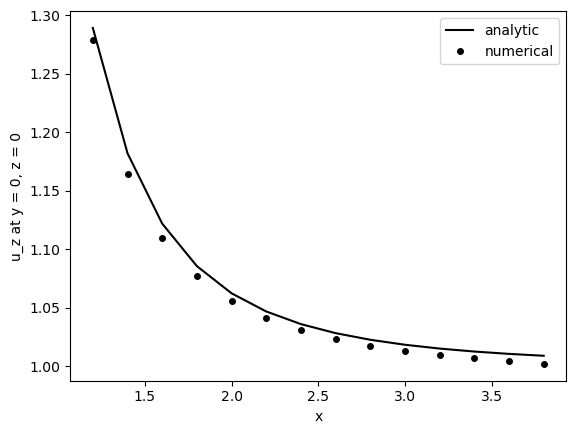

In [9]:
x_line = x[ic+6 : N-1]              # x = 1.2, 1.4, ..., 3.8
uz_num_line = uz[ic+6:N-1, ic, ic]  # y = 0, z = 0, i going outward

uz_exact_line = []
for xx in x_line:
    ux_e, uy_e, uz_e = velocity_analytic(xx, 0, 0)
    uz_exact_line.append(uz_e)

plt.plot(x_line, uz_exact_line, color='black', label='analytic')
plt.plot(x_line, uz_num_line, 'o', color='black', markersize=4, label='numerical')
plt.xlabel('x')
plt.ylabel('u_z at y = 0, z = 0')
plt.legend()
plt.show()

# 7) Streamlines
A streamline is a curve that is everywhere tangent to the velocity. A point $\mathbf{P}$ on it moves as
$$\frac{d\mathbf{P}}{dt} = \mathbf{u}(\mathbf{P})$$
This ODE is solved with **RK4**.

The velocity is known only on grid points, so between them it is found by **trilinear interpolation** 

In [10]:
def interp(field, px, py, pz):
    # lower corner of the small cube containing the point
    i = int((px + L)/h)
    j = int((py + L)/h)
    k = int((pz + L)/h)
    # fraction inside the cube (0 to 1)
    tx = (px - x[i])/h
    ty = (py - x[j])/h
    tz = (pz - x[k])/h
    # along x
    c00 = field[i,j,k]*(1-tx)     + field[i+1,j,k]*tx
    c10 = field[i,j+1,k]*(1-tx)   + field[i+1,j+1,k]*tx
    c01 = field[i,j,k+1]*(1-tx)   + field[i+1,j,k+1]*tx
    c11 = field[i,j+1,k+1]*(1-tx) + field[i+1,j+1,k+1]*tx
    # along y
    c0 = c00*(1-ty) + c10*ty
    c1 = c01*(1-ty) + c11*ty
    # along z
    return c0*(1-tz) + c1*tz

In [11]:
def f(t, P):
    vx = interp(ux, P[0], P[1], P[2])
    vy = interp(uy, P[0], P[1], P[2])
    vz = interp(uz, P[0], P[1], P[2])
    return np.array([vx, vy, vz])

def f_analytic(t, P):
    vx, vy, vz = velocity_analytic(P[0], P[1], P[2])
    return np.array([vx, vy, vz])

def RK4(func, tf, dt, P0, t0=0):
    t = np.arange(t0, tf + dt, dt)
    n = len(t)
    P = np.zeros((n, 3))
    P[0] = P0
    for i in range(n-1):
        k1 = func(t[i], P[i])
        k2 = func(t[i] + dt/2, P[i] + k1*dt/2)
        k3 = func(t[i] + dt/2, P[i] + k2*dt/2)
        k4 = func(t[i] + dt, P[i] + k3*dt)
        P[i+1] = P[i] + (k1 + 2*k2 + 2*k3 + k4)*dt/6
        # stop when the particle reaches the edge of the box
        if np.max(np.abs(P[i+1])) > L - 2*h:
            return P[:i+2]
    return P

In [12]:
radii = [0.2, 0.4, 0.6, 0.8, 1.0, 1.3, 1.6]
n_per_ring = 12

streamlines_num = []
streamlines_ana = []
for r0 in radii:
    for m in range(n_per_ring):
        angle = 2*np.pi*m/n_per_ring
        P0 = np.array([r0*np.cos(angle), r0*np.sin(angle), -3.5])
        streamlines_num.append(RK4(f, tf=15, dt=0.05, P0=P0))
        streamlines_ana.append(RK4(f_analytic, tf=15, dt=0.05, P0=P0))

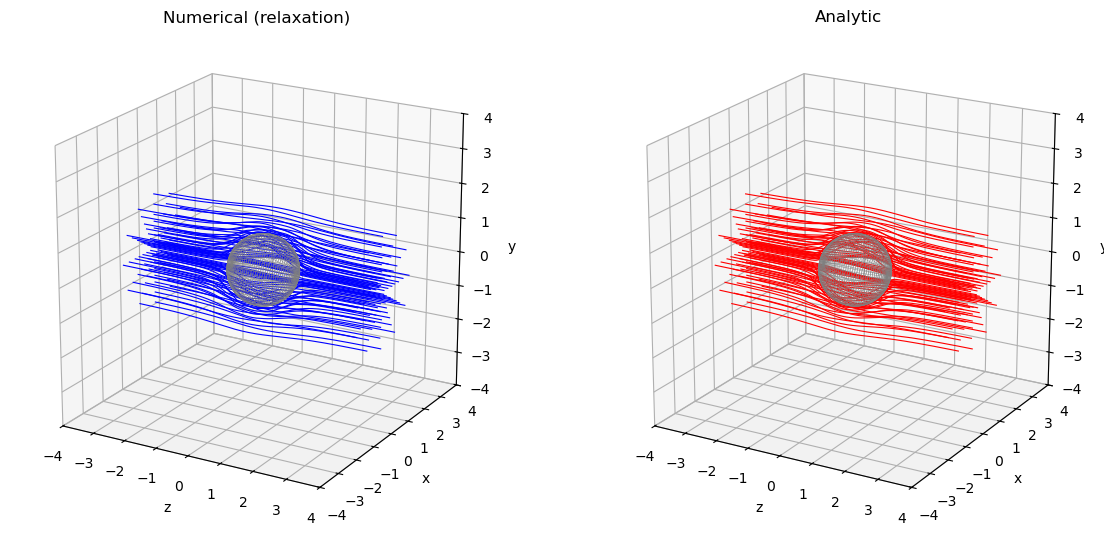

In [13]:
fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(121, projection='3d')
for P in streamlines_num:
    ax1.plot(P[:,0], P[:,1], P[:,2], color='blue', linewidth=0.8)
ax1.plot_wireframe(x_sph, y_sph, z_sph, color='gray', linewidth=0.3)
ax1.set_title('Numerical (relaxation)')

ax2 = fig.add_subplot(122, projection='3d')
for P in streamlines_ana:
    ax2.plot(P[:,0], P[:,1], P[:,2], color='red', linewidth=0.8)
ax2.plot_wireframe(x_sph, y_sph, z_sph, color='gray', linewidth=0.3)
ax2.set_title('Analytic')

for ax in [ax1, ax2]:
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)
    ax.set_zlim(-L, L)
    ax.set_box_aspect([1, 1, 1])
    ax.view_init(elev=20, azim=-60, vertical_axis='y')
plt.show()